In [ ]:
from google.colab import drive
import os
gdrive_path='/content/gdrive/MyDrive/ddpm'

# This will mount your google drive under 'MyDrive'
drive.mount('/content/gdrive', force_remount=True)
# In order to access the files in this notebook we have to navigate to the correct folder
os.chdir(gdrive_path)
# Check manually if all files are present
print(sorted(os.listdir()))

In [ ]:
!pip install --quiet -r requirements.txt

In [1]:
import os

import math
from collections import defaultdict

import numpy as np
import torch
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from tqdm import tqdm

from ddpm import DDPM
from visualization import visualize_dataset_mnist, visualize_mnist_samples, plot_image_grid

%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

plot_dir = "plots"
os.makedirs(plot_dir, exist_ok=True)
print(f"Plots will be saved to '{plot_dir}/'")

checkpoint_dir = "checkpoints_improved_ddpm"
os.makedirs(checkpoint_dir, exist_ok=True)
print(f"Checkpoints will be saved to '{checkpoint_dir}/'")

Using device: cpu
Plots will be saved to 'plots/'
Checkpoints will be saved to 'checkpoints_improved_ddpm/'


### Load MNIST dataset

In [3]:
batch_size = 128
tfs = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])
train_data = datasets.MNIST("./data", train=True, download=True, transform=tfs)
test_data = datasets.MNIST("./data", train=False, download=True, transform=tfs)

# using num_workers=4 and pin_memory=True for faster data loading
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)


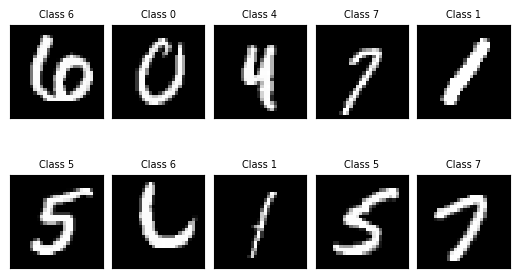

In [4]:
fig = visualize_dataset_mnist(train_data)
plt.show()

### Model initialization

In [5]:
# Shared parameters for the models
N_STEPS = 1000
IN_CHANNELS = 1
IMAGE_SIZE = 28
HIDDEN_DIM = 32
N_LAYERS = 2

# original DDPM
ddpm = DDPM(
    N=N_STEPS,
    type="unet",
    hidden_dim=HIDDEN_DIM,
    n_layers=N_LAYERS,
    in_channels=IN_CHANNELS,
    image_size=IMAGE_SIZE,
    beta_schedule="linear",
    var_schedule="fixed",
    loss_type="simple"
).to(device)
opt = torch.optim.Adam(ddpm.parameters(), lr=2e-4)

# improved DDPM, simple loss
ddpm_simple = DDPM(
    N=N_STEPS,
    type="unet",
    hidden_dim=HIDDEN_DIM,
    n_layers=N_LAYERS,
    in_channels=IN_CHANNELS,
    image_size=IMAGE_SIZE,
    beta_schedule="cosine",
    var_schedule="learned",
    loss_type="simple"
).to(device)
opt_simple = torch.optim.Adam(ddpm_simple.parameters(), lr=2e-4)

# improved DDPM, hybrid loss
ddpm_hybrid = DDPM(
    N=N_STEPS,
    type="unet",
    hidden_dim=HIDDEN_DIM,
    n_layers=N_LAYERS,
    in_channels=IN_CHANNELS,
    image_size=IMAGE_SIZE,
    beta_schedule="cosine",
    var_schedule="learned",
    loss_type="hybrid"
).to(device)
opt_hybrid = torch.optim.Adam(ddpm_hybrid.parameters(), lr=2e-4)

# improved DDPM, vlb loss
ddpm_vlb = DDPM(
    N=N_STEPS,
    type="unet",
    hidden_dim=HIDDEN_DIM,
    n_layers=N_LAYERS,
    in_channels=IN_CHANNELS,
    image_size=IMAGE_SIZE,
    beta_schedule="cosine",
    var_schedule="learned",
    loss_type="vlb"
).to(device)
opt_vlb = torch.optim.Adam(ddpm_vlb.parameters(), lr=2e-4)

# Improved DDPM, vlb loss (with importance sampling)
ddpm_vlb_is = DDPM(
    N=N_STEPS, type="unet", hidden_dim=HIDDEN_DIM, n_layers=N_LAYERS,
    in_channels=IN_CHANNELS, image_size=IMAGE_SIZE,
    beta_schedule="cosine", var_schedule="learned",
    loss_type="vlb",
    importance_sampling=True
).to(device)
opt_vlb_is = torch.optim.Adam(ddpm_vlb_is.parameters(), lr=2e-4)


### Forward process

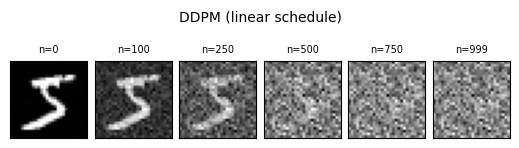

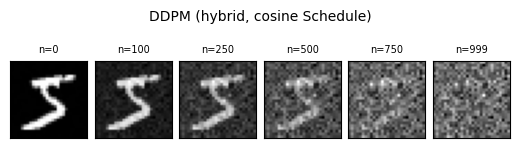

In [6]:
def visualize_forward_process(model, title, filename):
    x0, _ = train_data[0]
    x0 = x0.unsqueeze(0).to(device)

    timesteps = torch.tensor([0, 100, 250, 500, 750, 999], device=device)
    noisy_images = []
    labels = []

    epsilon = torch.randn_like(x0) # use the same noise for fair comparison

    for n in timesteps:
        alpha_bar_n = model.alpha_bar[n]
        x_n = torch.sqrt(alpha_bar_n) * x0 + torch.sqrt(1 - alpha_bar_n) * epsilon
        noisy_images.append(x_n.squeeze(0).cpu().numpy())
        labels.append(f"n={n.item()}")

    fig = plot_image_grid(noisy_images, labels, ncols=6)
    fig.suptitle(title, y=1.1, fontsize=10)

    filepath = os.path.join(plot_dir, filename)
    plt.savefig(filepath)
    plt.show()

visualize_forward_process(
    ddpm,
    "DDPM (linear schedule)",
    "01_forward_process_ddpm.png"
)

visualize_forward_process(
    ddpm_hybrid,
    "DDPM (hybrid, cosine Schedule)",
    "02_forward_process_ddpm_hybrid.png"
)


### Model training

In [7]:
def train_model(model, optimizer, max_epochs, model_name, checkpoint_dir, start_epoch=0, initial_losses=None):
    if initial_losses is None:
        all_losses = defaultdict(list)
    else:
        all_losses = initial_losses

    print(f"--- Starting training for: {model_name} (from epoch {start_epoch+1}) ---")

    for epoch in range(start_epoch, max_epochs):
        epoch_losses = defaultdict(list)

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{max_epochs}")
        for ix, (x, y) in enumerate(pbar):
            x = x.to(device)

            loss_dict = model.loss(x)
            loss = loss_dict["total_loss"]

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            for k, v in loss_dict.items():
                batch_loss_val = v.item()
                epoch_losses[k].append(batch_loss_val)
                all_losses[k].append(batch_loss_val)

            pbar.set_postfix({"loss": f"{loss.item():.4f}"})

        print(f"  => Epoch {epoch+1} complete. Mean Loss: {np.mean(epoch_losses['total_loss']):.4f}")

        checkpoint_path = os.path.join(checkpoint_dir, f"{model_name}_latest.pth")
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'losses': all_losses,
        }, checkpoint_path)

    print(f"--- Finished training for: {model_name} ---")
    return all_losses

MAX_EPOCHS = 20

#### Checkpoint-loading

In [8]:
start_epoch_ddpm = 20
losses_ddpm = None
checkpoint_path_ddpm = os.path.join(checkpoint_dir, "ddpm_latest.pth")

if os.path.isfile(checkpoint_path_ddpm):
    print(f"Loading checkpoint for 'DDPM': {checkpoint_path_ddpm}")

    checkpoint = torch.load(checkpoint_path_ddpm, map_location=device, weights_only=False)

    ddpm.load_state_dict(checkpoint['model_state_dict'], strict=False)
    opt.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch_ddpm = checkpoint['epoch']
    losses_ddpm = checkpoint['losses']

    print(f"  => Resuming 'DDPM' from epoch {start_epoch_ddpm + 1}")
else:
    print("Starting 'DDPM' training from scratch.")

Loading checkpoint for 'DDPM': checkpoints_improved_ddpm/ddpm_latest.pth
  => Resuming 'DDPM' from epoch 21


In [9]:
start_epoch_ddpm_simple = 20
losses_simple = None
checkpoint_path_simple = os.path.join(checkpoint_dir, "ddpm_simple_latest.pth")

if os.path.isfile(checkpoint_path_simple):
    print(f"Loading checkpoint for 'DDPM (simple)': {checkpoint_path_simple}")
    checkpoint = torch.load(checkpoint_path_simple, map_location=device, weights_only=False)

    ddpm_simple.load_state_dict(checkpoint['model_state_dict'], strict=False)
    opt_simple.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch_simple = checkpoint['epoch']
    losses_simple = checkpoint['losses']

    print(f"  => Resuming 'Improved DDPM' from epoch {start_epoch_simple + 1}")
else:
    print("Starting 'DDPM (simple)' training from scratch.")

Loading checkpoint for 'DDPM (simple)': checkpoints_improved_ddpm/ddpm_simple_latest.pth
  => Resuming 'Improved DDPM' from epoch 21


In [10]:
start_epoch_ddpm_hybrid = 20
losses_hybrid = None
checkpoint_path_hybrid = os.path.join(checkpoint_dir, "ddpm_hybrid_latest.pth")

if os.path.isfile(checkpoint_path_hybrid):
    print(f"Loading checkpoint for 'DDPM (hybrid)': {checkpoint_path_hybrid}")
    checkpoint = torch.load(checkpoint_path_hybrid, map_location=device, weights_only=False)

    ddpm_hybrid.load_state_dict(checkpoint['model_state_dict'], strict=False)
    opt_hybrid.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch_hybrid = checkpoint['epoch']
    losses_hybrid = checkpoint['losses']

    print(f"  => Resuming 'DDPM (hybrid)' from epoch {start_epoch_hybrid + 1}")
else:
    print("Starting 'DDPM (hybrid)' training from scratch.")

Loading checkpoint for 'DDPM (hybrid)': checkpoints_improved_ddpm/ddpm_hybrid_latest.pth
  => Resuming 'DDPM (hybrid)' from epoch 21


In [11]:
start_epoch_ddpm_vlb = 20
losses_vlb = None
checkpoint_path_vlb = os.path.join(checkpoint_dir, "ddpm_vlb_latest.pth")

if os.path.isfile(checkpoint_path_vlb):
    print(f"Loading checkpoint for 'DDPM (vlb)': {checkpoint_path_vlb}")
    checkpoint = torch.load(checkpoint_path_vlb, map_location=device, weights_only=False)

    ddpm_vlb.load_state_dict(checkpoint['model_state_dict'], strict=False)
    opt_vlb.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch_vlb = checkpoint['epoch']
    losses_vlb = checkpoint['losses']

    print(f"  => Resuming 'DDPM (vlb)' from epoch {start_epoch_vlb + 1}")
else:
    print("Starting 'DDPM (vlb)' training from scratch.")

Loading checkpoint for 'DDPM (vlb)': checkpoints_improved_ddpm/ddpm_vlb_latest.pth
  => Resuming 'DDPM (vlb)' from epoch 21


In [12]:
start_epoch_ddpm_vlb_is = 20
losses_vlb_is = None
checkpoint_path_vlb_is = os.path.join(checkpoint_dir, "ddpm_vlb_is_latest.pth")

if os.path.isfile(checkpoint_path_vlb_is):
    print(f"Loading checkpoint for 'DDPM (vlb with is)': {checkpoint_path_vlb_is}")
    checkpoint = torch.load(checkpoint_path_vlb_is, map_location=device, weights_only=False)

    ddpm_vlb_is.load_state_dict(checkpoint['model_state_dict'], strict=False)
    opt_vlb_is.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch_vlb_is = checkpoint['epoch']
    losses_vlb_is = checkpoint['losses']

    print(f"  => Resuming 'DDPM (vlb with is)' from epoch {start_epoch_vlb_is + 1}")
else:
    print("Starting 'DDPM (vlb with is)' training from scratch.")

Loading checkpoint for 'DDPM (vlb with is)': checkpoints_improved_ddpm/ddpm_vlb_is_latest.pth
  => Resuming 'DDPM (vlb with is)' from epoch 21


#### Model training

In [13]:
if start_epoch_ddpm < MAX_EPOCHS:
    losses_ddpm = train_model(
        ddpm,
        opt,
        MAX_EPOCHS,
        "ddpm",
        checkpoint_dir,
        start_epoch=start_epoch_ddpm,
        initial_losses=losses_ddpm
    )
else:
    print(f"'DDPM' training is already complete (reached {start_epoch_ddpm} epochs).")

'DDPM' training is already complete (reached 20 epochs).


In [14]:
if start_epoch_ddpm_simple < MAX_EPOCHS:
    losses_simple = train_model(
        ddpm_simple,
        opt_simple,
        MAX_EPOCHS,
        "ddpm_simple",
        checkpoint_dir,
        start_epoch=start_epoch_ddpm_simple,
        initial_losses=losses_simple
    )
else:
    print(f"'DDPM (simple)' training is already complete (reached {start_epoch_simple} epochs).")

'DDPM (simple)' training is already complete (reached 20 epochs).


In [15]:
if start_epoch_ddpm_hybrid < MAX_EPOCHS:
    losses_hybrid = train_model(
        ddpm_hybrid,
        opt_hybrid,
        MAX_EPOCHS,
        "ddpm_hybrid",
        checkpoint_dir,
        start_epoch=start_epoch_ddpm_hybrid,
        initial_losses=losses_hybrid
    )
else:
    print(f"'DDPM (hybrid)' training is already complete (reached {start_epoch_hybrid} epochs).")

'DDPM (hybrid)' training is already complete (reached 20 epochs).


In [16]:
if start_epoch_ddpm_vlb < MAX_EPOCHS:
    losses_vlb = train_model(
        ddpm_vlb,
        opt_vlb,
        MAX_EPOCHS,
        "ddpm_vlb",
        checkpoint_dir,
        start_epoch=start_epoch_ddpm_vlb,
        initial_losses=losses_vlb
    )
else:
    print(f"'DDPM (vlb)' training is already complete (reached {start_epoch_vlb} epochs).")

'DDPM (vlb)' training is already complete (reached 20 epochs).


In [17]:
if start_epoch_ddpm_vlb_is < MAX_EPOCHS:
    losses_vlb_is = train_model(
        ddpm_vlb_is,
        opt_vlb_is,
        MAX_EPOCHS,
        "ddpm_vlb_is",
        checkpoint_dir,
        start_epoch=start_epoch_ddpm_vlb_is,
        initial_losses=losses_vlb_is
    )
else:
    print(f"'DDPM (vlb with is)' training is already complete (reached {start_epoch_vlb_is} epochs).")

'DDPM (vlb with is)' training is already complete (reached 20 epochs).


#### Loss comparison

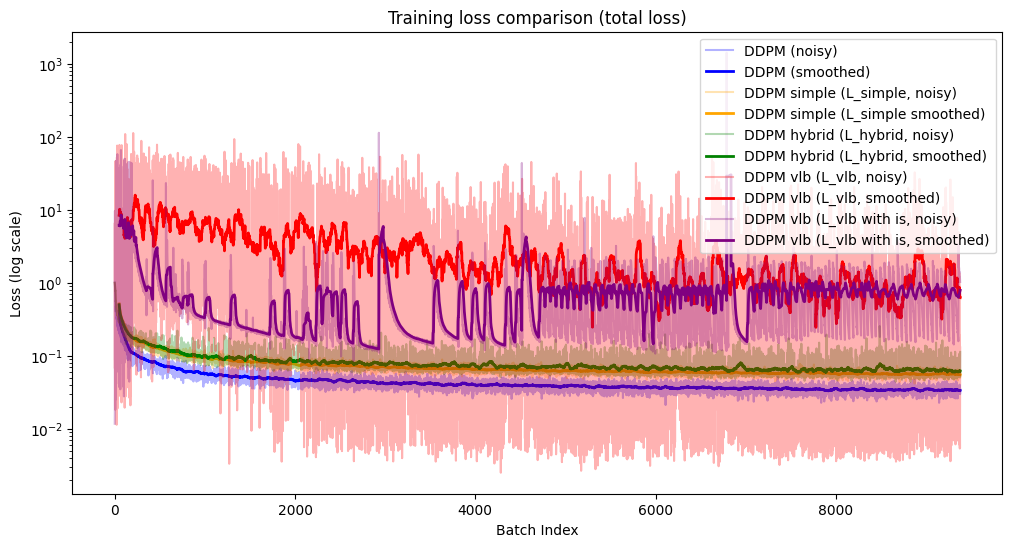

In [18]:
def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

window = 50
plt.figure(figsize=(12, 6))

loss_data_ddpm = losses_ddpm['total_loss']
x_raw_ddpm = np.arange(len(loss_data_ddpm))
plt.plot(
    x_raw_ddpm,
    loss_data_ddpm,
    label="DDPM (noisy)",
    alpha=0.3,
    color='blue'
)
smooth_losses_ddpm = moving_average(loss_data_ddpm, window)
x_smooth_ddpm = np.arange(window - 1, len(loss_data_ddpm))
plt.plot(
    x_smooth_ddpm,
    smooth_losses_ddpm,
    label="DDPM (smoothed)",
    color='blue',
    linewidth=2
)

loss_data_simple = losses_simple['L_simple']
x_raw_simple = np.arange(len(loss_data_simple))
plt.plot(
    x_raw_simple,
    loss_data_simple,
    label="DDPM simple (L_simple, noisy)",
    alpha=0.3,
    color='orange'
)
smooth_losses_simple = moving_average(loss_data_simple, window)
x_smooth_simple = np.arange(window - 1, len(loss_data_simple))
plt.plot(
    x_smooth_simple,
    smooth_losses_simple,
    label="DDPM simple (L_simple smoothed)",
    color='orange',
    linewidth=2
)

loss_data_hybrid = losses_hybrid['total_loss']
x_raw_hybrid = np.arange(len(loss_data_hybrid))
plt.plot(
    x_raw_hybrid,
    loss_data_hybrid,
    label="DDPM hybrid (L_hybrid, noisy)",
    alpha=0.3,
    color='green'
)
smooth_losses_hybrid = moving_average(loss_data_hybrid, window)
x_smooth_hybrid = np.arange(window - 1, len(loss_data_hybrid))
plt.plot(
    x_smooth_hybrid,
    smooth_losses_hybrid,
    label="DDPM hybrid (L_hybrid, smoothed)",
    color='green',
    linewidth=2
)

loss_data_vlb = losses_vlb['total_loss']
x_raw_vlb = np.arange(len(loss_data_vlb))
plt.plot(
    x_raw_vlb,
    loss_data_vlb,
    label="DDPM vlb (L_vlb, noisy)",
    alpha=0.3,
    color='red'
)
smooth_losses_vlb = moving_average(loss_data_vlb, window)
x_smooth_vlb = np.arange(window - 1, len(loss_data_vlb))
plt.plot(
    x_smooth_vlb,
    smooth_losses_vlb,
    label="DDPM vlb (L_vlb, smoothed)",
    color='red',
    linewidth=2
)

loss_data_vlb_is = losses_vlb_is['total_loss']
x_raw_vlb_is = np.arange(len(loss_data_vlb_is))
plt.plot(
    x_raw_vlb_is,
    loss_data_vlb_is,
    label="DDPM vlb (L_vlb with is, noisy)",
    alpha=0.3,
    color='purple'
)
smooth_losses_vlb_is = moving_average(loss_data_vlb_is, window)
x_smooth_vlb_is = np.arange(window - 1, len(loss_data_vlb_is))
plt.plot(
    x_smooth_vlb_is,
    smooth_losses_vlb_is,
    label="DDPM vlb (L_vlb with is, smoothed)",
    color='purple',
    linewidth=2
)

plt.title('Training loss comparison (total loss)')
plt.xlabel('Batch Index')
plt.ylabel('Loss (log scale)')
plt.legend()
plt.yscale('log')
# plt.ylim(0, 0.4)

filepath = os.path.join(plot_dir, "03_loss_comparison.png")
plt.savefig(filepath)
plt.show()

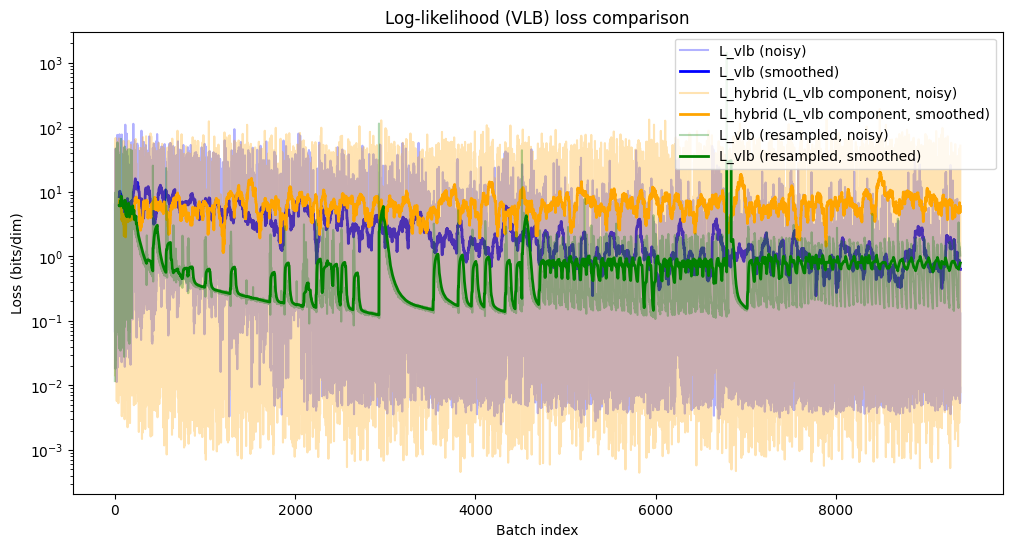

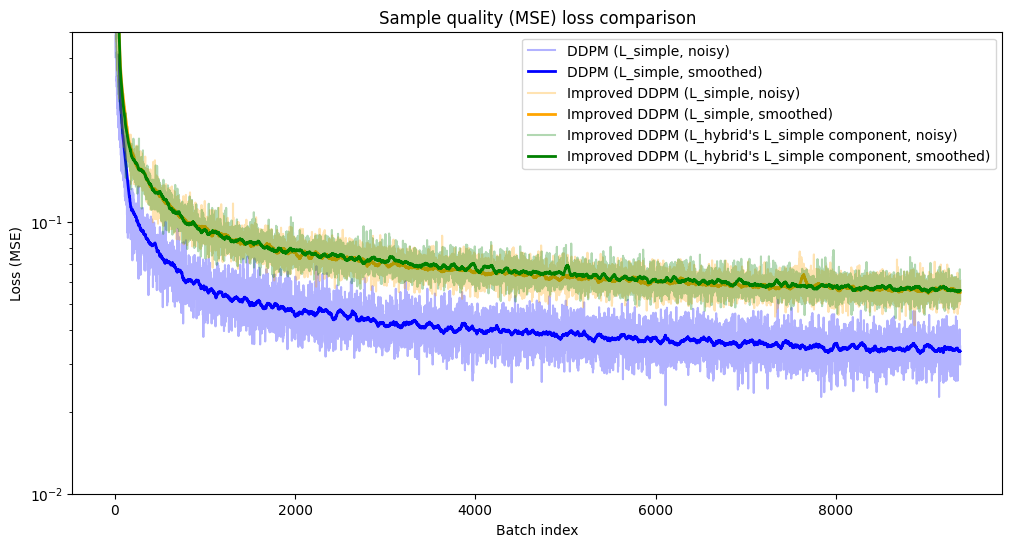

In [19]:
def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

window = 50

def create_comparison_plots(
    losses_ddpm,
    losses_simple,
    losses_hybrid,
    losses_vlb,
    losses_vlb_is,
    window_size,
    plot_dir
):
    """
    Generates two separate plots for VLB and MSE loss comparisons.

    Args:
        losses_ddpm: Loss dictionary from the original DDPM model.
        losses_simple: Loss dictionary from the 'ddpm_simple' model.
        losses_hybrid: Loss dictionary from the 'ddpm_hybrid' model.
        losses_vlb: Loss dictionary from the 'ddpm_vlb' model.
        losses_vlb_is: Loss dictionary from the 'ddpm_vlb_is' (importance sampled) model.
        window_size: The window size for the moving average.
        plot_dir: The directory to save the plots.
    """

    # --- log-likelihood (VLB) comparison ---
    # this plot compares all losses in 'bits per dimension'.

    plt.figure(figsize=(12, 6))

    if losses_vlb:
        data = losses_vlb['total_loss']
        x_raw = np.arange(len(data))
        plt.plot(x_raw, data, label="L_vlb (noisy)", alpha=0.3, color='blue')
        smooth_data = moving_average(data, window_size)
        x_smooth = np.arange(window_size - 1, len(data))
        plt.plot(x_smooth, smooth_data, label="L_vlb (smoothed)", color='blue', linewidth=2)

    if losses_hybrid:
        data = losses_hybrid['L_vlb']
        x_raw = np.arange(len(data))
        plt.plot(x_raw, data, label="L_hybrid (L_vlb component, noisy)", alpha=0.3, color='orange')
        smooth_data = moving_average(data, window_size)
        x_smooth = np.arange(window_size - 1, len(data))
        plt.plot(x_smooth, smooth_data, label="L_hybrid (L_vlb component, smoothed)", color='orange', linewidth=2)

    if losses_vlb_is:
        # plot 'L_vlb' (raw bits/dim) not 'total_loss' (weighted loss)
        # data = losses_vlb_is['total_loss']
        data = losses_vlb_is['total_loss']
        x_raw = np.arange(len(data))
        plt.plot(x_raw, data, label="L_vlb (resampled, noisy)", alpha=0.3, color='green')
        smooth_data = moving_average(data, window_size)
        x_smooth = np.arange(window_size - 1, len(data))
        plt.plot(x_smooth, smooth_data, label="L_vlb (resampled, smoothed)", color='green', linewidth=2)

    plt.title('Log-likelihood (VLB) loss comparison')
    plt.xlabel('Batch index')
    plt.ylabel('Loss (bits/dim)')
    plt.legend()
    plt.yscale('log')
    # plt.ylim(3.0, 5.0)

    filepath_vlb = os.path.join(plot_dir, "03a_vlb_loss_comparison.png")
    plt.savefig(filepath_vlb)
    plt.show()

    # --- sample quality (MSE) loss comparison ---
    # this plot compares all 'L_simple' (MSE) losses.

    plt.figure(figsize=(12, 6))

    if losses_ddpm:
        data = losses_ddpm['total_loss']
        x_raw = np.arange(len(data))
        plt.plot(x_raw, data, label="DDPM (L_simple, noisy)", alpha=0.3, color='blue')
        smooth_data = moving_average(data, window_size)
        x_smooth = np.arange(window_size - 1, len(data))
        plt.plot(x_smooth, smooth_data, label="DDPM (L_simple, smoothed)", color='blue', linewidth=2)

    if losses_simple:
        data = losses_simple['total_loss']
        x_raw = np.arange(len(data))
        plt.plot(x_raw, data, label="Improved DDPM (L_simple, noisy)", alpha=0.3, color='orange')
        smooth_data = moving_average(data, window_size)
        x_smooth = np.arange(window_size - 1, len(data))
        plt.plot(x_smooth, smooth_data, label="Improved DDPM (L_simple, smoothed)", color='orange', linewidth=2)

    if losses_hybrid:
        data = losses_hybrid['L_simple']
        x_raw = np.arange(len(data))
        plt.plot(x_raw, data, label="Improved DDPM (L_hybrid's L_simple component, noisy)", alpha=0.3, color='green')
        smooth_data = moving_average(data, window_size)
        x_smooth = np.arange(window_size - 1, len(data))
        plt.plot(x_smooth, smooth_data, label="Improved DDPM (L_hybrid's L_simple component, smoothed)", color='green', linewidth=2)

    plt.title('Sample quality (MSE) loss comparison')
    plt.xlabel('Batch index')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.yscale('log')
    plt.ylim(0.01, 0.5)

    filepath_mse = os.path.join(plot_dir, "03b_mse_loss_comparison.png")
    plt.savefig(filepath_mse)
    plt.show()

create_comparison_plots(
    losses_ddpm,
    losses_simple,
    losses_hybrid,
    losses_vlb,
    losses_vlb_is,
    window,
    plot_dir
)

### Sampling

In [ ]:
def generate_and_save_samples(model, model_name, filename, num_steps=-1):
    """
    Generates and saves samples from a model, allowing for a specified
    number of sampling steps.
    """

    if num_steps <= 0 or num_steps > model.N:
        steps_desc = f"full {model.N} steps"
    else:
        steps_desc = f"{num_steps} steps"

    title = f"Samples: {model_name} ({steps_desc})"
    print(f"Sampling from {model_name} using {steps_desc}...")

    with torch.no_grad():
        samples = model.sample(20, device, num_steps=num_steps)

    fig = visualize_mnist_samples(samples)
    fig.suptitle(title, y=1.05, fontsize=10)

    filepath = os.path.join(plot_dir, filename)
    fig.savefig(filepath)
    plt.show()

generate_and_save_samples(
    ddpm,
    "DDPM",
    "04_samples_ddpm_full.png"
    # num_steps=-1
)

generate_and_save_samples(
    ddpm_hybrid,
    "DDPM (Hybrid)",
    "05_samples_ddpm_hybrid_full.png",
    num_steps=-1
)

generate_and_save_samples(
    ddpm_hybrid,
    "DDPM (Hybrid)",
    "05_samples_ddpm_hybrid_fast_100.png",
    num_steps=100
)

generate_and_save_samples(
    ddpm_hybrid,
    "DDPM (Hybrid)",
    "05_samples_ddpm_hybrid_fast_50.png",
    num_steps=50
)

### Reverse process

In [ ]:
def visualize_reverse_process(model, title, filename, num_steps=-1, num_plots=5):
    """
    Visualizes the reverse process, supporting both full and strided sampling.
    """
    print(f"Visualizing reverse process for: {title}")
    num_samples = 5

    if num_steps <= 0 or num_steps > model.N:
        timesteps = list(reversed(range(model.N)))
        total_steps = model.N
        desc = f"Sampling (full {model.N} steps)..."
    else:
        timesteps = torch.linspace(model.N - 1, 0, num_steps, device=device).round().long().tolist()
        total_steps = num_steps
        desc = f"Sampling ({num_steps} steps)..."

    plot_indices = np.linspace(0, len(timesteps) - 1, num_plots, dtype=int)
    timesteps_to_plot = [timesteps[i] for i in plot_indices]

    image_shape = (model.in_channels, model.image_size, model.image_size)
    z_n = torch.randn((num_samples, *image_shape), device=device)

    intermediate_samples = []
    with torch.no_grad():
        for n in tqdm(timesteps, total=total_steps, desc=desc):
            n_tensor = torch.full((num_samples,), n, dtype=torch.long, device=device)

            if n in timesteps_to_plot:
                intermediate_samples.append((n, z_n.cpu()))

            normalized_n = n_tensor.float() / model.N
            model_output = model.model(z_n, normalized_n)
            z_n = model._p_sample(model_output, z_n, n_tensor)

    if timesteps[-1] not in timesteps_to_plot:
         intermediate_samples.append((timesteps[-1], z_n.cpu()))

    plot_images = []
    plot_labels = []

    intermediate_samples.sort(key=lambda x: x[0], reverse=True)

    for n, images_batch in intermediate_samples:
        for i in range(num_samples):
            plot_images.append(images_batch[i].squeeze(0))
            plot_labels.append(f"Sample {i+1}\nn={n}")

    fig = plot_image_grid(plot_images, plot_labels, ncols=num_samples)
    fig.suptitle(title, y=1.05, fontsize=10)

    filepath = os.path.join(plot_dir, filename)
    plt.savefig(filepath)
    print(f"Saved reverse process plot to {filepath}")
    plt.show()

In [ ]:
visualize_reverse_process(
    ddpm,
    "Reverse process: DDPM (full 1000 steps)",
    "06_reverse_process_ddpm_full.png"
    # num_steps=-1 is default
)

visualize_reverse_process(
    ddpm_hybrid,
    "Reverse process: DDPM (hybrid, full 1000 steps)",
    "07_reverse_process_ddpm_hybrid_full.png"
)

visualize_reverse_process(
    ddpm_hybrid,
    "Reverse process: DDPM (hybrid, 100 steps)",
    "07_reverse_process_ddpm_hybrid_fast.png",
    num_steps=100
)